In [1]:
!pip install kaggle

In [2]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [3]:
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
100% 163M/163M [00:07<00:00, 23.0MB/s]



In [4]:
# extracting the compessed Dataset
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from google.colab.patches import cv2_imshow
import matplotlib.image as mpimg


In [6]:
with_musk_file=os.listdir('/content/data/with_mask')
wothout_musk_file=os.listdir('/content/data/without_mask')

In [7]:
print(with_musk_file[:5])
print(wothout_musk_file[0:5])
print(len(with_musk_file))
print(len(wothout_musk_file))

['with_mask_1574.jpg', 'with_mask_3353.jpg', 'with_mask_2373.jpg', 'with_mask_1432.jpg', 'with_mask_1078.jpg']
['without_mask_1013.jpg', 'without_mask_914.jpg', 'without_mask_344.jpg', 'without_mask_1932.jpg', 'without_mask_3281.jpg']
3725
3828


In [8]:
with_musk_lab=[1]*3725
without_mask_lab=[0]*3828
labes=with_musk_lab+without_mask_lab
print(with_musk_lab[:5])
print(without_mask_lab[:5])
print(len(labes))

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]
7553


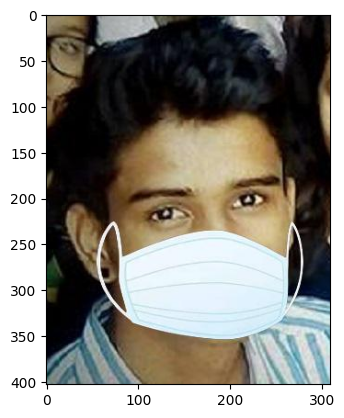

In [9]:
img=mpimg.imread('/content/data/with_mask/with_mask_1000.jpg')
imgplot=plt.imshow(img)
plt.show()

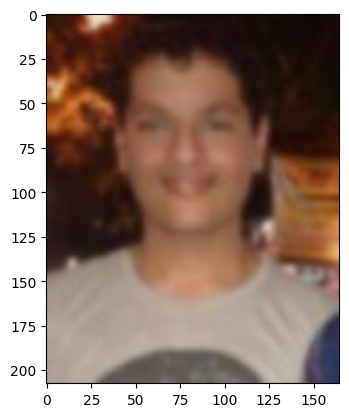

In [10]:
img=mpimg.imread('/content/data/without_mask/without_mask_1295.jpg')
imgplot=plt.imshow(img)
plt.show()

In [11]:
with_musk_path='/content/data/with_mask/'
data=[]
for img_file in with_musk_file:
  image=Image.open(with_musk_path + img_file)
  image=image.resize((128,128))
  image=image.convert('RGB')
  image=np.array(image)
  data.append(image)


without_mask_path='/content/data/without_mask/'
for img_file in wothout_musk_file:
  image=Image.open(without_mask_path + img_file)
  image=image.resize((128,128))
  image=image.convert('RGB')
  image=np.array(image)
  data.append(image)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [12]:
len(data[0])

128

In [13]:
data[0].shape

(128, 128, 3)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [254, 254, 254]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [254, 254, 254]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [254, 254, 254]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [ 61,  61,  53],
        [ 63,  63,  55],
        [ 62,  62,  54]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [ 60,  60,  52],
        [ 69,  69,  61],
        [ 71,  71,  63]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [ 62,  62,  54],
        [ 74,  74,  66],
        [ 83,  83,  75]]], dtype=uint8)
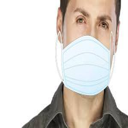

In [14]:
data[0]

In [15]:
x=np.array(data)
y=np.array(labes)

In [16]:
print(x.shape)
print(y.shape)

(7553, 128, 128, 3)
(7553,)


In [17]:
from sklearn.model_selection import train_test_split

In [18]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [19]:
x_train

array([[[[ 60,  47,  39],
         [ 61,  46,  38],
         [ 67,  49,  39],
         ...,
         [147, 113,  76],
         [144, 110,  73],
         [143, 109,  72]],

        [[ 54,  41,  32],
         [ 65,  50,  40],
         [ 84,  66,  53],
         ...,
         [153, 119,  81],
         [145, 111,  73],
         [142, 108,  70]],

        [[ 65,  49,  36],
         [ 81,  64,  51],
         [104,  84,  68],
         ...,
         [154, 121,  80],
         [149, 115,  74],
         [148, 113,  73]],

        ...,

        [[173, 153, 116],
         [174, 153, 116],
         [174, 150, 114],
         ...,
         [ 37,  22,  17],
         [ 39,  24,  19],
         [ 41,  26,  21]],

        [[181, 151, 117],
         [179, 149, 116],
         [177, 146, 115],
         ...,
         [ 38,  23,  18],
         [ 39,  24,  18],
         [ 40,  25,  18]],

        [[180, 145, 113],
         [180, 145, 114],
         [181, 146, 117],
         ...,
         [ 38,  23,  18],
        

In [20]:
x_train_scale=x_train/255
x_test_scale=x_test/255

In [21]:
from keras.utils import to_categorical
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

# Or simply:
import tensorflow as tf

In [22]:
y_train_cate=to_categorical(y_train,num_classes=2)
y_test_cate=to_categorical(y_test,num_classes=2)

In [23]:



from keras.models import Sequential
from keras import layers

cnn_model = Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Add more conv layers for better performance
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(2, activation='softmax')  # Binary output
])

cnn_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

cnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,400,706 (28.23 MB)

 Trainable params: 7,400,706 (28.23 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
cnn_model.compile(optimizer='adam',
              loss='categorical_crossentropy',  # Change this
              metrics=['accuracy'])         # Use 'accuracy' not 'acc'

In [25]:
print(np.isnan(x_train_scale).sum())  # Should be 0
print(np.isinf(x_train_scale).sum())  # Should be 0

0
0


In [26]:
# Use the one-hot encoded labels
history = cnn_model.fit(x_train_scale, y_train_cate,  # Use y_train_cate not Y_train
                        validation_split=0.1,
                        epochs=5,
                        batch_size=32)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 99s 574ms/step - accuracy: 0.7942 - loss: 0.4523 - val_accuracy: 0.8777 - val_loss: 0.3118
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 90s 529ms/step - accuracy: 0.8867 - loss: 0.3008 - val_accuracy: 0.8975 - val_loss: 0.2410
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 141s 521ms/step - accuracy: 0.9075 - loss: 0.2335 - val_accuracy: 0.9157 - val_loss: 0.2093
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 87s 511ms/step - accuracy: 0.9250 - loss: 0.1943 - val_accuracy: 0.9157 - val_loss: 0.2377
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 88s 520ms/step - accuracy: 0.9343 - loss: 0.1628 - val_accuracy: 0.9207 - val_loss: 0.2366


In [27]:
loss,acc=cnn_model.evaluate(x_test_scale,y_test_cate)
print('Test accuracy:',acc)

48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.9246 - loss: 0.1936
Test accuracy: 0.9245532751083374


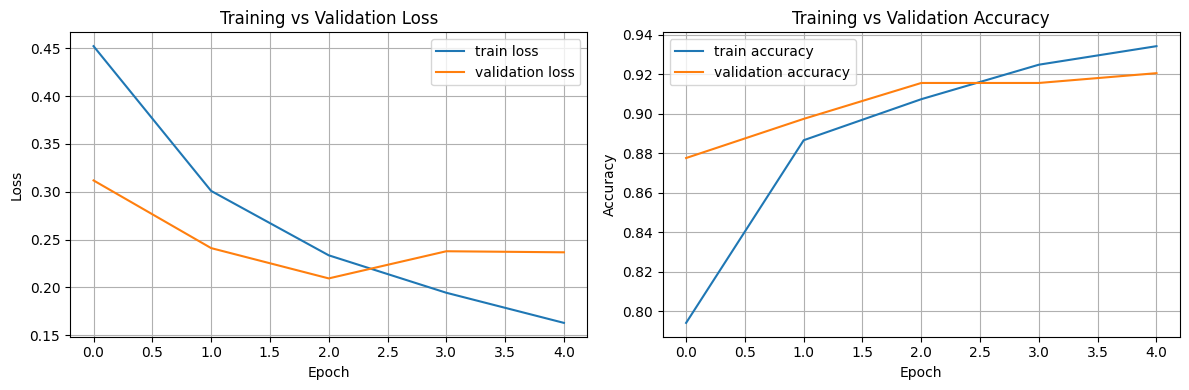

In [28]:

# Use history directly
h = history

# Plot the loss value
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

# Plot the accuracy value
plt.subplot(1, 2, 2)
plt.plot(h.history['accuracy'], label='train accuracy')      # Changed: 'accuracy' not 'acc'
plt.plot(h.history['val_accuracy'], label='validation accuracy')  # Changed: 'val_accuracy' not 'val_acc'
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Path of the image to be predicted: /content/data/without_mask/without_mask_1.jpg


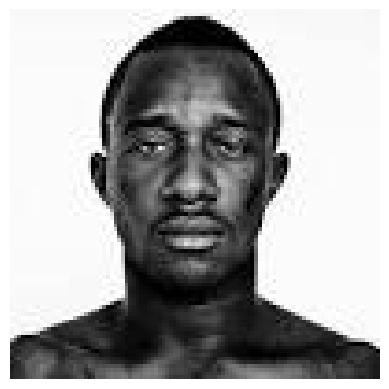

Raw prediction: [[0.04741896 0.95258105]]
Predicted label: 1, Confidence: 95.26%
The person in the image is wearing a mask


In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Get input path
input_image_path = input('Path of the image to be predicted: ')

# Load image (OpenCV loads as BGR)
input_image = cv2.imread(input_image_path)

# Check if image loaded successfully
if input_image is None:
    print("Error: Could not load image. Check the path.")
else:
    # Display image using matplotlib (BGR to RGB conversion)
    plt.imshow(cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    # Preprocess
    input_image_resized = cv2.resize(input_image, (128, 128))
    input_image_rgb = cv2.cvtColor(input_image_resized, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    input_image_scaled = input_image_rgb.astype('float32') / 255.0

    # Reshape for model
    input_image_reshaped = np.reshape(input_image_scaled, [1, 128, 128, 3])

    # Predict (use cnn_model, not model)
    input_prediction = cnn_model.predict(input_image_reshaped, verbose=0)
    print("Raw prediction:", input_prediction)

    # Handle different output types
    if input_prediction.shape[1] == 1:  # Binary (sigmoid, 1 output)
        input_pred_label = 1 if input_prediction[0][0] > 0.5 else 0
        confidence = input_prediction[0][0] if input_pred_label == 1 else 1 - input_prediction[0][0]
    else:  # Categorical (softmax, 2 outputs)
        input_pred_label = np.argmax(input_prediction)
        confidence = np.max(input_prediction)

    print(f"Predicted label: {input_pred_label}, Confidence: {confidence:.2%}")

    # Output result
    if input_pred_label == 1:
        print('The person in the image is wearing a mask')
    else:
        print('The person in the image is NOT wearing a mask')

In [30]:
from PIL import Image
import numpy as np

input_image_path = input('Path of the image to be predicted: ')

# Load and preprocess
img = Image.open(input_image_path).convert('RGB')
img = img.resize((128, 128))
img_array = np.array(img, dtype='float32') / 255.0
img_reshaped = np.reshape(img_array, [1, 128, 128, 3])

# Predict
prediction = cnn_model.predict(img_reshaped, verbose=0)
pred_label = np.argmax(prediction)

result = "wearing a mask" if pred_label == 1 else "NOT wearing a mask"
print(f"The person in the image is {result}")

Path of the image to be predicted: /content/data/without_mask/without_mask_1.jpg
The person in the image is wearing a mask


In [31]:
from keras.models import load_model
# cnn_model=load_model('face_mask_detection_model.h5') # This line caused the FileNotFoundError
cnn_model.save('face_mask_detection_model.h5')

In [32]:
from google.colab import files
files.download('face_mask_detection_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>